# Data Analysis

# Clinic 3: Classification with missing values & inbalanced data

## DELIVERABLES (DEADLINE 06/Mar late night, wildcards possible)

Instructions for the deliverable: 

* Make sure that you include a proper amount/mix of comments, results and code.

* In the end, make sure that all cells are executed properly and everything you need to show is in your (execucted) notebook.

* You are asked to deliver **only your executed notebook file, .ipnyb** and nothing else. Enjoy!

* The second part of the assignment is purposefully left open-ended.

## Score breakdown

Question | Points
--- | ---
[Question 1](#q1) | 3
[Question 2](#q2) | 6
[Question 3](#q3) | 3
[Question 4](#q4) | 4
[Question 5](#q5) | 4
[Question 6](#q6) | 6
[Question 7](#q7) | 6
[Question 8](#q8) | 4
[Question 9](#q9) | 6
[Question 10](#q10)| 18
Total | 60

This score will be scaled down to 1 and that will be your final clinic score.

## Learning Goals

By the end of this clinic, you should be able to:

- Build classification models for credit default prediction
- Quantify and handle class imbalance
- Understand why accuracy fails in imbalanced settings
- Compare:
  - Accuracy
  - ROC-AUC
  - Precision-Recall AUC
  - Confusion matrices
- Use:
  - Cross-validation
  - Regularization
  - Class weighting
  - Threshold tuning

# 0. The dataset

### What is LendingClub?

LendingClub is a peer-to-peer lending platform that connects borrowers with investors. Instead of borrowing from a traditional bank, individuals apply for loans through the platform. Investors then fund these loans and receive returns if borrowers repay successfully.

The dataset used in this clinic contains historical loan data, including:

- Borrower characteristics
- Loan characteristics
- Credit risk indicators
- Loan repayment outcomes

Our goal is to predict whether a loan will **default**.

---

### What is the Prediction Task?

We focus on a binary classification problem:

- `default = 1` → Loan was **Charged Off** (borrower failed to repay)
- `default = 0` → Loan was **Fully Paid**

This is a classic **credit risk modeling** problem.

It is also a naturally **imbalanced dataset**, since most borrowers repay their loans.

### Structure of the Dataset

The dataset contains several categories of variables.

---

### 1️⃣ Borrower Employment & Income Information

- `emp_title` – Job title of the borrower  
- `emp_length` – Length of employment (in years)
- `annual_income` – Borrower’s reported annual income (in USD)
- `verified_income` – Whether income was verified (yes/no)
- `annual_income_joint` – Joint annual income (if co-borrower e.g. for couples)  
- `verification_income_joint` – Whether joint income was verified  
---

### 2️⃣ Housing & Application Information

- `state` – U.S. state of residence
- `homeownership` – three options: RENT / OWN / MORTGAGE  
- `application_type` – Individual or joint application  
- `loan_purpose` – Purpose of the loan (e.g., debt consolidation, credit card, car)  
---

### 3️⃣ Debt & Financial Burden Measures

- `debt_to_income` – Debt-to-income ratio
- `debt_to_income_joint` – Joint DTI (if applicable)  
- `installment` – Monthly loan payment (in USD)
- `loan_amount` – Total loan amount requested (in USD)
- `term` – Loan duration (in months)
- `interest_rate` – Interest rate assigned to the loan (in %)
---

### 4️⃣ Credit History Indicators

- `earliest_credit_line` – Year of first credit line  
- `delinq_2y` – Delinquencies in past 2 years (*delinquency* means failure to fulfill a financial obligation)
- `inquiries_last_12m` – Credit inquiries in last 12 months  
- `months_since_last_delinq` - months since ast delinquency 
- `months_since_90d_late` - a 90-day delinquency is a serious milestone in credit reporting
- `num_accounts_30d_past_due` - number of accounts that are 30 days past due
- `num_accounts_120d_past_due` - number of accounts that are 120 days past due
- `current_accounts_delinq` - number of accounts in delinquency
- `num_historical_failed_to_pay` - times that failed a payment in the past
- `public_record_bankrupt` - whether exists a public record for bankruptcy
- `tax_liens` - yes/no: a lien is a legal claim placed by some authority (usually public) against a person’s property 
---

### 5️⃣ Credit Utilization & Account Structure

- `total_credit_lines` - # of credit lines
- `open_credit_lines` - # of open credit ines
- `total_credit_limit` - credit limit (in USD)
- `total_credit_utilized` - credit used (in USD)
- `account_never_delinq_percent` - %
- `num_satisfactory_accounts` - # of accounts
- `num_open_cc_accounts` - # of accounts
- `num_cc_carrying_balance` - # credit cards carrying balance
- `num_active_debit_accounts` - # of accounts
- `total_debit_limit` - debit limit (in USD)
- `num_mort_accounts` - # of mortgage accounts
- `accounts_opened_24m` - # of accounts opened in the last 24 months
---

### 6️⃣ LendingClub Risk Grades

- `grade` – Risk category (A–G), internal assessment by LendingClub
- `sub_grade` – More granular risk classification, also by LendingClub
---

### 7️⃣ Loan Outcome Variables

- `balance` – Remaining balance  (in USD)
- `paid_total` – Total amount paid (in USD)
- `paid_principal` – Principal repaid (in USD)
- `paid_interest` – Interest paid (in USD)
- `paid_late_fees` – Late fees paid (in USD)
- `issue_month` – month/year of issue
- `initial_listing_status` – whole or functional  
- `disbursement_method` – How funds were disbursed 

- `default` – Final loan outcome (0 or 1) This is our prediction variable.

In [43]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.api import OLS
#from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
%matplotlib inline
import seaborn as sns
sns.set(context='paper')

In [44]:
# Load the loans dataset
loans = pd.read_csv('loans_full_schemaa.csv')

# Display basic information about the dataset
print(f"Dataset shape: {loans.shape}")
loans.head()

,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,...,sub_grade,issue_month,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees,default
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,...,C3,Mar/18,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0,0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,...,C1,Feb/18,whole,Cash,4651.37,499.12,348.63,150.49,0.0,0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,...,D1,Feb/18,fractional,Cash,1824.63,281.80,175.37,106.43,0.0,0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,...,A3,Jan/18,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0,0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,...,C3,Mar/18,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0,1


In [45]:
# Display column names and data types
loans.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 55 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   str    
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  str    
 3   homeownership                     10000 non-null  str    
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  str    
 6   debt_to_income                    9976 non-null   float64
 7   annual_income_joint               1495 non-null   float64
 8   verification_income_joint         1455 non-null   str    
 9   debt_to_income_joint              1495 non-null   float64
 10  delinq_2y                         10000 non-null  int64  
 11  months_since_last_delinq          4342 non-null   float64
 12  earliest_credit_

## Part 1: Pre-processing

Before building any model, remove variables that would not have been known at the time the loan *was issued*. Using post-outcome information is called **data leakage** (which we covered in class) and leads to unrealistically high performance.

### Question 1: Data leakage

1. Which variables in this dataset must be excluded due to data leakage?
2. Why are they invalid predictors?
3. What would happen to model performance if you kept them?
4. Write code that would remove the variables from the dataframe.

Hint: Look for variables that describe repayment amounts, balances, late fees, or the final loan outcome.


**Your answer goes here**
1. - balance
   - paid_total
   - paid_principal
   - paid_interest
   - paid_late_fees

2. Because they describe what happened after the loan was issued.These variables contain future information.Using them means the model has access to information from the future --> Data Leakage !

3. The model would achieve unrealistically high accuracy and possibly near-perfect ROC-AUC
--> Look extremely good, but it would completely fail in real-world deployment because in real life, those values don’t exist at prediction time.

In [46]:
leakage_cols = [
    "balance",
    "paid_total",
    "paid_principal",
    "paid_interest",
    "paid_late_fees"
]

loans = loans.drop(columns=leakage_cols)

In [47]:
# sanity check
loans.columns

Index(['emp_title', 'emp_length', 'state', 'homeownership', 'annual_income',
       'verified_income', 'debt_to_income', 'annual_income_joint',
       'verification_income_joint', 'debt_to_income_joint', 'delinq_2y',
       'months_since_last_delinq', 'earliest_credit_line',
       'inquiries_last_12m', 'total_credit_lines', 'open_credit_lines',
       'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'public_record_bankr

### Question 2: Analyze Missing Values

Now that we got rid of the "leakage" variables, it's important to understand the extent and pattern of missing data in the dataset.

1. Calculate the percentage of missing values for each column in the dataset.
2. Identify the top 10 columns with the highest percentage of missing values.
3. Create a proper visualization (bar plot or other) showing missing value patterns. We give bonus points if you come up with a suitable visualization going beyond the standard (which is still perfcetly fine)

Afterwards, discuss:

4. Which variables have substantial missingness (>20%)?

5. Are there any patterns in the missingness that could be informative (refer to the MAR, MNAR, MCAR concepts from week 1)?

6. How might you handle these missing values in your modeling pipeline? Implement some function to handle it on your dataframe.

7. Could the missingness itself be informative? (e.g., missing employment length might indicate self-employment)

In [48]:
# Your code here: Calculate and visualize missing values
#####################
# Hint: Use .isnull().sum() and .isnull().mean() * 100
#####################

# 1. Calculate the percentage of missing values for each column
missing_counts = loans.isnull().sum()
missing_percentages = loans.isnull().mean() * 100

print(f"\nTotal number of rows: {len(loans)}")
print(f"Total number of columns: {len(loans.columns)}")
print(f"\nColumns with missing values: {(missing_counts > 0).sum()}")
print(f"Columns with NO missing values: {(missing_counts == 0).sum()}")
print(missing_percentages)


Total number of rows: 10000
Total number of columns: 50

Columns with missing values: 10
Columns with NO missing values: 40
emp_title                            8.33
emp_length                           8.17
state                                0.00
homeownership                        0.00
annual_income                        0.00
verified_income                      0.00
debt_to_income                       0.24
annual_income_joint                 85.05
verification_income_joint           85.45
debt_to_income_joint                85.05
delinq_2y                            0.00
months_since_last_delinq            56.58
earliest_credit_line                 0.00
inquiries_last_12m                   0.00
total_credit_lines                   0.00
open_credit_lines                    0.00
total_credit_limit                   0.00
total_credit_utilized                0.00
num_collections_last_12m             0.00
num_historical_failed_to_pay         0.00
months_since_90d_late              

In [49]:
# 2. Identify the top 10 columns with the highest percentage of missing values
top_10_missing = missing_percentages.sort_values(ascending=False).head(10)

top_10_missing

verification_income_joint           85.45
annual_income_joint                 85.05
debt_to_income_joint                85.05
months_since_90d_late               77.15
months_since_last_delinq            56.58
months_since_last_credit_inquiry    12.71
emp_title                            8.33
emp_length                           8.17
num_accounts_120d_past_due           3.18
debt_to_income                       0.24
dtype: float64

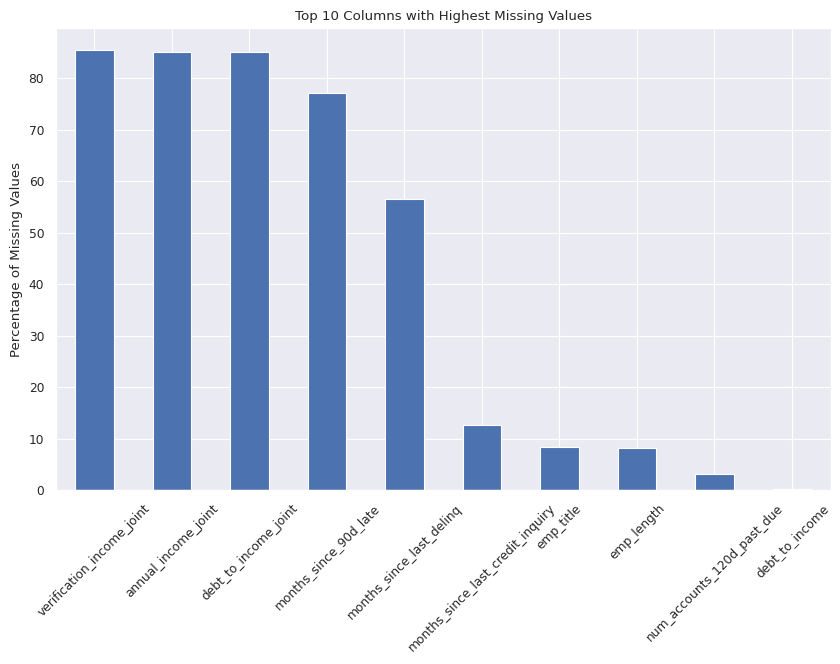

In [50]:
# 3. Create visualization showing missing value patterns
plt.figure(figsize=(10,6))
top_10_missing.plot(kind='bar')
plt.ylabel("Percentage of Missing Values")
plt.title("Top 10 Columns with Highest Missing Values")
plt.xticks(rotation=45)
plt.show()

The bar plot shows that the highest missingness occurs in the joint application variables (annual_income_joint, verification_income_joint, debt_to_income_joint), with more than 80% missing values. This suggests structural missingness, likely because most loans are individual applications. Variables related to delinquency timing also exhibit substantial missingness, which may indicate that many borrowers never experienced such events rather than representing random data loss.

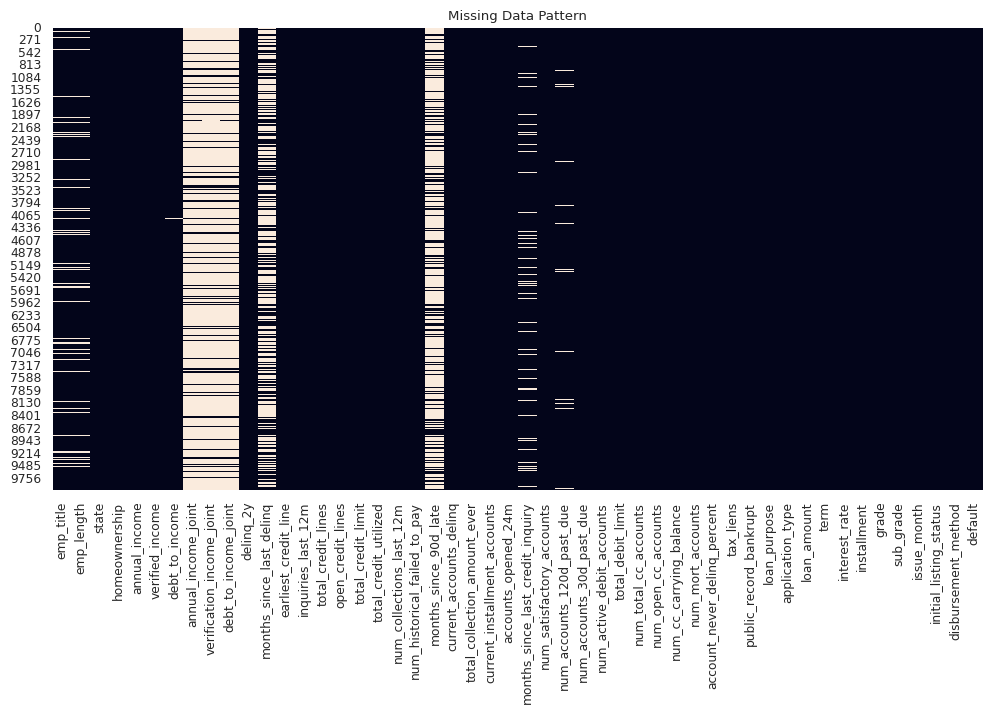

In [51]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(loans.isnull(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()

The missing data heatmap reveals clear vertical bands of missing values, especially for joint-income variables and delinquency timing variables. 

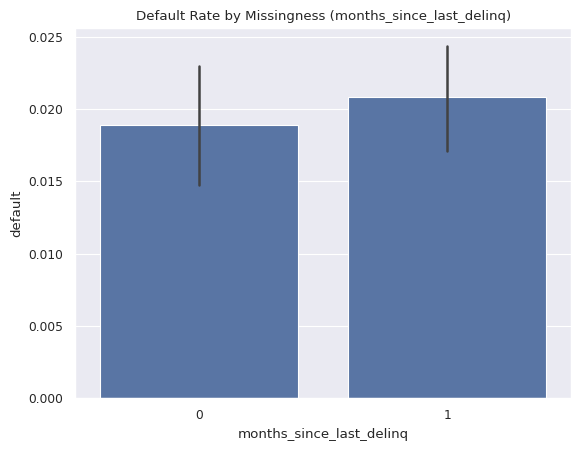

In [52]:
missing_indicator = loans['months_since_last_delinq'].isnull().astype(int)

pd.crosstab(missing_indicator, loans['default'], normalize='index')

sns.barplot(
    x=missing_indicator,
    y=loans['default']
)
plt.title("Default Rate by Missingness (months_since_last_delinq)")
plt.show()

The bar plot comparing default rates by missingness in months_since_last_delinq suggests a slight difference in default probability between observations with and without missing values. This indicates that missingness itself may carry predictive information and should potentially be encoded as a feature rather than simply imputed.

**Your answer goes here**

4. The variables with substantial missingness (>20%) are:

- annual_income_joint (~85%)

- verification_income_joint (~85%)

- debt_to_income_joint (~85%)

- months_since_90d_late (~77%)

- months_since_last_delinq (~57%)

The first three variables correspond to joint income information and are missing in most observations because the majority of applications are individual rather than joint. The delinquency timing variables are also frequently missing, likely because many borrowers have never experienced such delinquency events.

5. The missingness does not appear to be completely random (MCAR). Instead, there are clear structural patterns suggesting the data is likely Missing At Random (MAR). For example, joint income variables are missing mainly for individual applications, which explains their high missing rate. Similarly, delinquency timing variables are likely missing because borrowers have never experienced these events. These patterns suggest that missingness is related to observable characteristics in the data rather than being purely random.
   
6. Different strategies can be applied depending on the type of missingness:

- Joint income variables (annual_income_joint, verification_income_joint, debt_to_income_joint): these could either be removed due to their very high missing rate or encoded using an indicator variable capturing whether the application is joint.

- Delinquency timing variables (months_since_last_delinq, months_since_90d_late): missing values likely indicate that no delinquency occurred, so they could be imputed with a large value or replaced with 0 along with a binary indicator for missingness.

- Other variables with small missing percentages (e.g., emp_title, emp_length, months_since_last_credit_inquiry): these could be imputed using the median for numerical variables or treated as a separate category for categorical variables.

7. Yes, missingness itself may carry predictive information. For example, missing values in variables such as months_since_last_delinq or months_since_90d_late may indicate that the borrower has never experienced such delinquency events, which could be associated with lower credit risk. Similarly, missing employment information might reflect self-employment or irregular employment situations. Therefore, creating indicator variables capturing whether a value is missing could potentially improve model performance.

In [53]:
#here incude code to handle the missing values
def handle_missing_values(df):
    
    # Drop joint income variables (too many missing values)
    df = df.drop(columns=[
        'annual_income_joint',
        'verification_income_joint',
        'debt_to_income_joint',
        'months_since_last_credit_inquiry',
        'num_accounts_120d_past_due',
        'debt_to_income'
    ])
    
    # Impute delinquency timing variables
    df['months_since_last_delinq'] = df['months_since_last_delinq'].fillna(999)
    df['months_since_90d_late'] = df['months_since_90d_late'].fillna(999)

    # Fill missing job titles with "Unknown"
    df['emp_title'] = df['emp_title'].fillna("Unknown")
    
    return df

### Question 3: Quantify the Imbalance

We now focus on the binary variable `default`, which is the one we want to predict.

1. Compute the percentage of:
   - Defaulted loans 
   - Fully paid loans 
2. Which class is the majority?
3. Which class is the minority?
4. What would be the accuracy of a classifier that predicts all loans as Fully Paid?
5. Make an appropriate plot to show the class imbalance

In [54]:
#your code here

# 1. Compute the percentage of defaulted and fully paid loans
# Compute class distribution
class_counts = loans['default'].value_counts()
class_percentages = loans['default'].value_counts(normalize=True) * 100

print("Class counts:\n", class_counts)
print("\nClass percentages:\n", class_percentages)

# 2 & 3. Identify majority and minority classes
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

print(f"Majority class: {majority_class}")
print(f"Minority class: {minority_class}")

# Calculate imbalance ratio
imbalance_ratio = class_counts[0] / class_counts[1]

print(f"Imbalance ratio (Fully Paid / Default): {imbalance_ratio:.2f}")

# Accuracy of a naive classifier --> accuracy = proportion of fully paid loans

naive_accuracy = class_percentages[0]

print(f"Accuracy if predicting all loans as Fully Paid: {naive_accuracy:.2f}%")
# appears high but is misleading because it completely ignores the minority class (defaults)

Class counts:
 default
0    9800
1     200
Name: count, dtype: int64

Class percentages:
 default
0    98.0
1     2.0
Name: proportion, dtype: float64
Majority class: 0
Minority class: 1
Imbalance ratio (Fully Paid / Default): 49.00
Accuracy if predicting all loans as Fully Paid: 98.00%


**Your answer goes here**

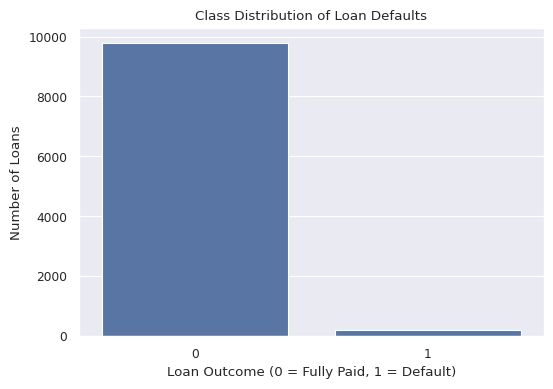

In [55]:
# Visualization: Class Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='default', data=loans)

plt.title("Class Distribution of Loan Defaults")
plt.xlabel("Loan Outcome (0 = Fully Paid, 1 = Default)")
plt.ylabel("Number of Loans")

plt.show()

The dataset shows a strong class imbalance, with the majority of loans being fully paid and only a small fraction defaulting. This means the "Fully Paid" class is the majority class while "Default" is the minority class. A naive classifier that predicts all loans as fully paid would achieve a very high accuracy equal to the proportion of fully paid loans. However, this model would fail to detect any defaults, making accuracy a misleading metric in this context.

### Question 4: Why Accuracy Fails

1. Why is accuracy not an appropriate metric in this dataset?
2. In credit lending, we assume that the cost of missing a default (i.e. lose an entire loan because a bad decision to hand out the loan was made) is approx. and on average 10,000 USD and the cost of rejecting a good borrower (i.e. the lost profit for rejecting a loan that would pay in ful) is 500 USD. Which is more costly:

   - A False Negative (missed defaulter)?
   - A False Positive (rejected good borrower)?
   
   Support your conclusions with calculations and plots.
   
3. Which metric would better reflect business risk?

**Your answer goes here**

In [56]:
#calculations for the cost
from sklearn.metrics import confusion_matrix

cost_FN = 10000
cost_FP = 500
print("FN is", cost_FN / cost_FP, "times more costly than FP")

#ideas: consider the amounts of FP and FN (given the dataset) or even extreme classifiers (e.g. giving all loans)

FN is 20.0 times more costly than FP


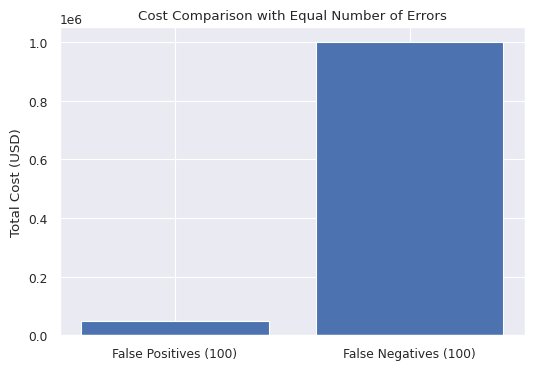

In [57]:
# Hypothetical equal number of errors
fp = 100
fn = 100

cost_fp_total = fp * cost_FP
cost_fn_total = fn * cost_FN

print("Cost from False Positives:", cost_fp_total)
print("Cost from False Negatives:", cost_fn_total)

# Plot comparison
labels = ["False Positives (100)", "False Negatives (100)"]
costs = [cost_fp_total, cost_fn_total]

plt.figure(figsize=(6,4))
plt.bar(labels, costs)
plt.ylabel("Total Cost (USD)")
plt.title("Cost Comparison with Equal Number of Errors")
plt.show()

To illustrate the asymmetric business cost of errors, we assume a classifier produces the same number of false positives and false negatives (100 each). Despite having the same number of mistakes, the total cost of false negatives is dramatically higher (1,000,000 vs 50,000)

**Your answer goes here**

1. Accuracy is misleading in this dataset because the classes are imbalanced (most loans are fully paid). A model can achieve very high accuracy by predicting the majority class (Fully Paid) for almost everyone, while failing to detect defaults (the class we care most about). In addition, accuracy weights all mistakes equally, but in lending the cost of errors is highly asymmetric (missing a default is far more expensive than rejecting a good borrower).


3.A better metric should emphasize detecting the minority class and reflect asymmetric costs. Metrics such as Recall (Sensitivity) for the default class, Precision–Recall AUC, or a cost-sensitive evaluation (expected cost = FP·500 + FN·10000) are more appropriate than accuracy. In credit risk, optimizing recall for defaults (while controlling false positives) and tuning the decision threshold based on business cost is often preferred:
- For imbalanced data where the positive class is rare and important → PR-AUC is often more informative than ROC-AUC.

- For explicit business alignment → expected cost / cost-weighted loss is the most direct.

### Question 5: Identify Valid Features

1. We are now considering the rest of the features (after removing leakage variables).

   Identify which features are:
   - Numerical?
   - Categorical?
   - Ordinal?

2. Which categorical variables need encoding?

3. Are there any variabes with high cardinality (i.e. high number of categories) that you woud consider removing?

In [58]:
# Your code here: (if needed)
feature_types = {
    "Numerical": [
        "emp_length","annual_income","debt_to_income","delinq_2y",
        "earliest_credit_line","inquiries_last_12m","total_credit_lines",
        "open_credit_lines","total_credit_limit","total_credit_utilized",
        "num_collections_last_12m","num_historical_failed_to_pay",
        "months_since_last_delinq","months_since_90d_late",
        "current_accounts_delinq","total_collection_amount_ever",
        "accounts_opened_24m","months_since_last_credit_inquiry",
        "num_satisfactory_accounts","num_accounts_120d_past_due",
        "num_accounts_30d_past_due","num_active_debit_accounts",
        "total_debit_limit","num_total_cc_accounts","num_open_cc_accounts",
        "num_cc_carrying_balance","num_mort_accounts",
        "account_never_delinq_percent","tax_liens","public_record_bankrupt",
        "loan_amount","term","interest_rate","installment"
    ],
    
    "Categorical": [
        "state","homeownership","verified_income","loan_purpose",
        "application_type","initial_listing_status",
        "disbursement_method","issue_month","emp_title"
    ],
    
    "Ordinal": [
        "grade","sub_grade"
    ]
}


table = pd.DataFrame([
    {"Feature Type": k, "Variables": ", ".join(v)}
    for k,v in feature_types.items()
])

table
#####################

,Feature Type,Variables
0,Numerical,"emp_length, annual_income, debt_to_income, del..."
1,Categorical,"state, homeownership, verified_income, loan_pu..."
2,Ordinal,"grade, sub_grade"


**Your answer goes here**

2. Encoding -- > Machine learning models cannot handle raw text categories. Therefore these must be encoded:
- state
- homeownership
- verified_income
- loan_purpose
- application_type
- initial_listing_status
- disbursement_method
- issue_month
- grade
- sub_grade
- emp_title

The ypical encoding methods are :
- One-hot encoding (most common)
- Ordinal encoding (for grade/sub_grade)

3. (High-cardinality variables --> have many unique categories --> can cause problems when using one-hot encoding.

The main candidate here is: emp_title --> probably contains hundreds or thousands of unique job titles.

In [59]:
#

## Part 2: Fit a logistic model ignoring missing values

Now by this point, we assume that you have dealt with missing values, possible data leakage and have done some first pre-processing decisions. Feel free to continue the exploration here, but keep in ind that Questions 6-8 are still informative (we don't care about performance yet). You will explore an open model in Question 10.

### Question 6: Logistic Regression (Baseline)

1. Fit a logistic regression model.
2. Report:
   - Accuracy
   - Confusion matrix
   - ROC-AUC
3. How many defaults does the model correctly detect?
4. How many defaults does it miss?

If you ignore the missingness `sklearn` might crash (`ValueError: Input contains NaN, infinity or a value too large for dtype('float64')`.) So you can also consider not using that variable in the model

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score, 
                              roc_curve, classification_report)
from sklearn.preprocessing import LabelEncoder

In [61]:
# Your code here: 
########################
########################

# make sure to remove leakage variables (if not done already)


# make sure to remove other variables you identified before
exclude_vars = [
    "annual_income_joint",
    "verification_income_joint",
    "debt_to_income_joint",
    "default"
]
# Get feature columns
# feature_cols = [col for col in loans.columns if col not in exclude_vars]

print(f"\nFeature Selection:")
print(f"  Total columns in dataset: {len(loans.columns)}")
print(f"  Excluded columns: {len(exclude_vars)}")
# print(f"  Features for modeling: {len(feature_cols)}")


Feature Selection:
  Total columns in dataset: 50
  Excluded columns: 4


In [62]:
# Step 2: Handle missing values - simple approach for baseline
# if you haven't done it before
loans = handle_missing_values(loans)

In [63]:
# Encoding
# Drop emp_title for the baseline because it is too coymplex
if 'emp_title' in loans.columns:
    loans = loans.drop(columns=['emp_title'])

# Dropping 'grade' because 'sub-grade' already contains this info and to prevent multicolinearity
if 'grade' in loans.columns:
    loans = loans.drop(columns=['grade'])

# Ordinal Encoding for the Ordinal variables (Use of Generative AI here for efficiency in the lines by using more complex clauses)
sub_grade_mapping = {sub: idx for idx, sub in enumerate(sorted(loans['sub_grade'].unique()))}
loans['sub_grade'] = loans['sub_grade'].map(sub_grade_mapping)

# Extracting year and month as standard numbers
loans['issue_month'] = pd.to_datetime(loans['issue_month'], format='%b/%y')
loans['issue_year'] = loans['issue_month'].dt.year
loans['issue_month_num'] = loans['issue_month'].dt.month
loans = loans.drop(columns=['issue_month'])

# One-Hot encoding for the remaining nominal categorical variables
nominal_vars = [
    'state',
    'homeownership',
    'verified_income',
    'loan_purpose',
    'initial_listing_status',
    'disbursement_method',
    'application_type'
]
loans = pd.get_dummies(loans, columns=nominal_vars, drop_first=True, dtype=int)

# Verification
print(f"Remaining categorical columns: {len(loans.select_dtypes(include=['object']).columns)}")
print(f"New dataset shape: {loans.shape}")
print(loans.select_dtypes(include=['object']).columns.tolist())

Remaining categorical columns: 0
New dataset shape: (10000, 103)
[]


In [64]:
# Step 3: (possibly) numerical and categorical features

X = loans.drop(columns=['default'] + exclude_vars, errors='ignore')
y = loans['default'].copy()

numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"\n  Numerical features: {len(numerical_cols)}")
print(f"  Categorical features: {len(categorical_cols)}")
print(loans.select_dtypes(include=['object']).columns.tolist())


  Numerical features: 102
  Categorical features: 0
[]


In [65]:
# Step 4: Train-test split

# Here we incorporate a different train/test split due to the high-inbalance. 
# We do stratisfy but we also as the split method to have at least 50 data points or 30%.
# That is for the case that we have very few data points (not appicable here)

n_defaults = y.sum()
min_test_defaults = max(int(n_defaults * 0.3), 25)  # At least 50 or 30%

print(f"Total defaults in dataset: {n_defaults}")
print(f"Target defaults in test set: {min_test_defaults}")

# If dataset too small, use larger test set
if n_defaults < 100:
    test_size = 0.4  # Use 40% for test if very few defaults
    print(f"⚠ Warning: Only {n_defaults} defaults total - using test_size={test_size}")
else:
    test_size = 0.3

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=1983,
    stratify=y
)

print(f"\nTrain-Test Split:")
print(f"  Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Train default rate: {y_train.mean()*100:.2f}%")
print(f"  Test default rate: {y_test.mean()*100:.2f}%")

Total defaults in dataset: 200
Target defaults in test set: 60

Train-Test Split:
  Training set: 7,000 samples (70.0%)
  Test set: 3,000 samples (30.0%)
  Train default rate: 2.00%
  Test default rate: 2.00%


In [66]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import pandas as pd

# We used generative AI to design the solution to the convergence warning, we used imputing for the missing values so that we wouldn't have to drop columns that may be useful for us

imputer = SimpleImputer(strategy='median')
# we fit on the training data and only transform the test data
X_train_imputed = imputer.fit_transform(X_train)
# transforming test data
X_test_imputed = imputer.transform(X_test)

# Scaling the data, since we get a convergence warning when fitting the model.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Convert back to pandas DataFrames (since sklearn outputs raw numpy arrays)
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"Missing values in X_train after imputation: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test after imputation: {X_test.isnull().sum().sum()}")

Missing values in X_train after imputation: 0
Missing values in X_test after imputation: 0


In [67]:
# Step 5: Fit Logistic Regression

log_reg = LogisticRegression(max_iter=1000, random_state=1983)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",1983
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Reminder: The Confusion Matrix & Some Useful Functions

- the samples that are +ive and the classifier predicts as +ive are called True Positives (TP)
- the samples that are -ive and the classifier predicts (wrongly) as +ive are called False Positives (FP)
- the samples that are -ive and the classifier predicts as -ive are called True Negatives (TN)
- the samples that are +ive and the classifier predicts as -ive are called False Negatives (FN)

A classifier produces a confusion matrix which looks like this:

![confusionmatrix](./confusionmatrix_360.png)


IMPORTANT NOTE: In `sklearn`, to obtain the confusion matrix in the form above, always have the observed `y` first, i.e.: use as `confusion_matrix(y_true, y_pred)`



In [68]:
# Step 6: Make predictions and evaluate
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# 2a. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n1. ACCURACY: {accuracy*100:.2f}%")

# Compare to naive baseline
naive_accuracy = (y_test == 0).mean()
print(f"   Naive baseline (always predict 0): {naive_accuracy*100:.2f}%")
print(f"   Improvement: {(accuracy - naive_accuracy)*100:.2f} percentage points")

# 2b. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"\n2. CONFUSION MATRIX:")
print(f"\n                 Predicted")
print(f"                 0 (Paid)    1 (Default)")
print(f"   Actual  0    {tn:7,}     {fp:7,}")
print(f"           1    {fn:7,}     {tp:7,}")

# 3. Correctly detected and missed defaults
print(f"\n3. DEFAULT DETECTION:")
print(f"   Total actual defaults in test set: {tp + fn:,}")
print(f"   ✓ Correctly detected (TP): {tp:,} ({tp/(tp+fn)*100:.2f}%)")
print(f"   ✗ Missed defaults (FN): {fn:,} ({fn/(tp+fn)*100:.2f}%)")

# 4. Missed defaults
print(f"\n4. MISSED DEFAULTS:")
print(f"   The model MISSED {fn:,} out of {tp+fn:,} defaults")
print(f"   This is a {fn/(tp+fn)*100:.1f}% miss rate (False Negative Rate)")
print(f"   At $10,000 per missed default: ${fn * 10000:,.0f} in potential losses")



1. ACCURACY: 98.00%
   Naive baseline (always predict 0): 98.00%
   Improvement: 0.00 percentage points

2. CONFUSION MATRIX:

                 Predicted
                 0 (Paid)    1 (Default)
   Actual  0      2,916          24
           1         36          24

3. DEFAULT DETECTION:
   Total actual defaults in test set: 60
   ✓ Correctly detected (TP): 24 (40.00%)
   ✗ Missed defaults (FN): 36 (60.00%)

4. MISSED DEFAULTS:
   The model MISSED 36 out of 60 defaults
   This is a 60.0% miss rate (False Negative Rate)
   At $10,000 per missed default: $360,000 in potential losses


In [69]:
# Additional metrics
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nADDITIONAL METRICS:")
print(f"   Precision: {precision*100:.2f}% (of predicted defaults, how many are real?)")
print(f"   Recall: {recall*100:.2f}% (of real defaults, how many did we catch?)")
print(f"   F1-Score: {f1:.4f}")

# 2c. ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n   ROC-AUC: {roc_auc:.4f}")


ADDITIONAL METRICS:
   Precision: 50.00% (of predicted defaults, how many are real?)
   Recall: 40.00% (of real defaults, how many did we catch?)
   F1-Score: 0.4444

   ROC-AUC: 0.9578


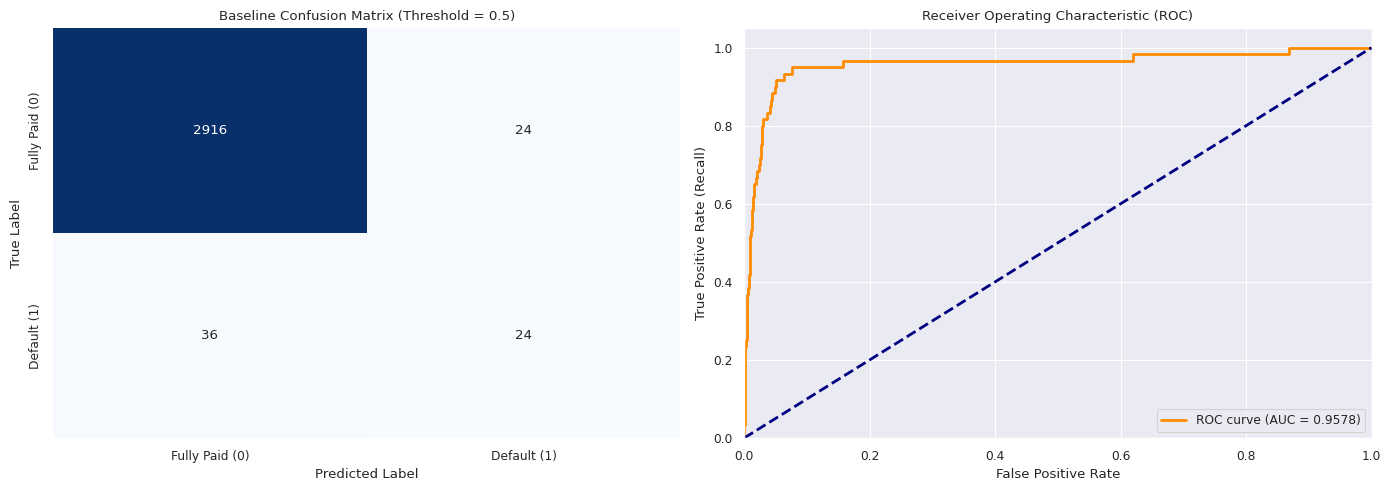

In [70]:
#add 1-2 plots for the results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Baseline Confusion Matrix (Threshold = 0.5)')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticklabels(['Fully Paid (0)', 'Default (1)'])
axes[0].set_yticklabels(['Fully Paid (0)', 'Default (1)'])

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('Receiver Operating Characteristic (ROC)')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

**Your answer goes here : We give you the most methods for metrics etc. it's up to you to interpret the numbers and do nice plots**

### Question 7: Threshold Analysis

As you recall from the lectures, the default threshold for the logistic regression classifier (which is a probabilistic classifier) is 0.5. But is that the best? Below we evaluate different options.

1. Evaluate the model at thresholds:
   - 0.5
   - 0.3
   - 0.2
2. For each threshold, compute:
   - Confusion matrix
   - Recall (default class)
   - Precision (default class)
3. How does lowering the threshold change:
   - False positives?
   - False negatives?
4. Why is 0.5 unlikely to be optimal in credit risk?

In [71]:
######HERE CODE
######
# Define thresholds to test
thresholds = [0.5, 0.3, 0.2]

# Store results
results = []

for threshold in thresholds:
    # Make predictions at this threshold
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    # Compute metrics
    cm = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm.ravel()
    
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    results.append({
        'threshold': threshold,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        'recall': recall,
        'precision': precision
    })
    
    # Print results
    print(f"\n{'='*70}")
    print(f"THRESHOLD = {threshold}")
    print(f"{'='*70}")
    print(f"\nConfusion Matrix:")
    print(f"                 Predicted")
    print(f"                 Paid      Default")
    print(f"   Actual Paid   {tn:6,}    {fp:6,}")
    print(f"          Default {fn:6,}    {tp:6,}")
    
    print(f"\nMetrics:")
    print(f"   Recall (TPR):    {recall*100:.2f}% - catches {recall*100:.1f}% of defaults")
    print(f"   Precision:       {precision*100:.2f}% - {precision*100:.1f}% of predictions are correct")
    print(f"   False Negatives: {fn:,} (missed defaults)")
    print(f"   False Positives: {fp:,} (rejected good loans)")

# Create DataFrame for comparison
df_results = pd.DataFrame(results)

print(f"\n{'='*70}")
print("COMPARISON ACROSS THRESHOLDS")
print(f"{'='*70}")
print(f"\n{'Threshold':<12}{'Recall':<12}{'Precision':<12}{'FP':<10}{'FN':<10}")
print(f"{'-'*56}")
for _, row in df_results.iterrows():
    print(f"{row['threshold']:<12.1f}{row['recall']*100:<11.1f}%{row['precision']*100:<11.1f}%"
          f"{row['fp']:<10,}{row['fn']:<10,}")

# Visualizations

#plot and compare confusion matrices

#plot and compare metrics across thresholds


THRESHOLD = 0.5

Confusion Matrix:
                 Predicted
                 Paid      Default
   Actual Paid    2,916        24
          Default     36        24

Metrics:
   Recall (TPR):    40.00% - catches 40.0% of defaults
   Precision:       50.00% - 50.0% of predictions are correct
   False Negatives: 36 (missed defaults)
   False Positives: 24 (rejected good loans)

THRESHOLD = 0.3

Confusion Matrix:
                 Predicted
                 Paid      Default
   Actual Paid    2,897        43
          Default     23        37

Metrics:
   Recall (TPR):    61.67% - catches 61.7% of defaults
   Precision:       46.25% - 46.2% of predictions are correct
   False Negatives: 23 (missed defaults)
   False Positives: 43 (rejected good loans)

THRESHOLD = 0.2

Confusion Matrix:
                 Predicted
                 Paid      Default
   Actual Paid    2,883        57
          Default     20        40

Metrics:
   Recall (TPR):    66.67% - catches 66.7% of defaults
   Preci

**Your answer goes here**
0.5 is the most aggressive threshold. It rejects the least number of good loans but also misses the most defaults. As we will see further ahead, this is a potentially fatal strategy for the bank, as defaults will cost them a lot of money. Choosing 0.5 as a threshold will lead to the bank giving out bad loans at a higher rate.

---

### Question 8: Refit with Imbalance Handling

1. Fit logistic regression with `class_weight='balanced'`.
2. Compare results to the baseline model:
   - ROC-AUC
   - Recall
   - Precision
3. Does the model detect more defaults?
4. What is the trade-off?


In [72]:
# Your code here: Calculate and visualize if appropriate
#####################
# We basically do the same as before, but we now set the class weight:
log_reg_balanced = LogisticRegression(max_iter=10000, random_state=198, class_weight='balanced')
log_reg_balanced.fit(X_train, y_train)
y_pred_bal = log_reg_balanced.predict(X_test)
y_pred_proba_bal = log_reg_balanced.predict_proba(X_test)[:, 1]
roc_auc_bal = roc_auc_score(y_test, y_pred_proba_bal)
recall_bal = recall_score(y_test, y_pred_bal)
precision_bal = precision_score(y_test, y_pred_bal)

print("--- Balanced Model Metrics ---")
print(f"ROC-AUC: {roc_auc_bal:.4f}")
print(f"Recall: {recall_bal*100:.2f}%")
print(f"Precision: {precision_bal*100:.2f}%\n")
# Now we compare the metrics of the balanced model to the "unbalanced" model:
print("--- Comparison (Baseline -> Balanced) ---")
print(f"ROC-AUC: {roc_auc:.4f} -> {roc_auc_bal:.4f}")
print(f"Recall: {recall*100:.2f}% -> {recall_bal*100:.2f}%")
print(f"Precision: {precision*100:.2f}% -> {precision_bal*100:.2f}%\n")

# Now we use the confusion matrix to quantify the results:
cm_bal = confusion_matrix(y_test, y_pred_bal)
tn_bal, fp_bal, fn_bal, tp_bal = cm_bal.ravel()

print(f"--- Balanced Model Default Detection ---")
print(f"Total actual defaults in test set: {tp_bal + fn_bal}")
print(f"Correctly detected (TP): {tp_bal} ({(tp_bal/(tp_bal+fn_bal))*100:.2f}%)")
print(f"Missed defaults (FN): {fn_bal}")
print(f"False Positives (Rejected good loans): {fp_bal}")

#####################

--- Balanced Model Metrics ---
ROC-AUC: 0.9515
Recall: 90.00%
Precision: 19.78%

--- Comparison (Baseline -> Balanced) ---
ROC-AUC: 0.9578 -> 0.9515
Recall: 66.67% -> 90.00%
Precision: 41.24% -> 19.78%

--- Balanced Model Default Detection ---
Total actual defaults in test set: 60
Correctly detected (TP): 54 (90.00%)
Missed defaults (FN): 6
False Positives (Rejected good loans): 219


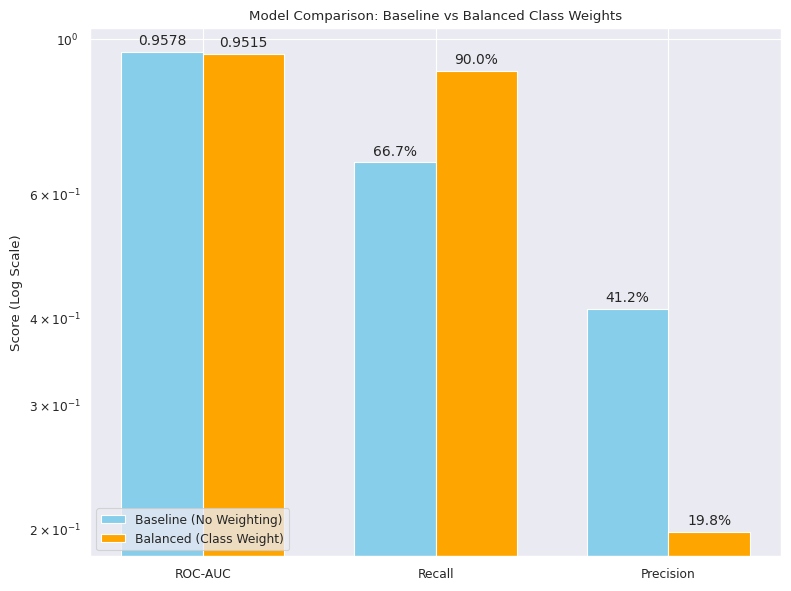

In [73]:
metrics = ['ROC-AUC', 'Recall', 'Precision']
baseline_scores = [roc_auc, recall, precision]
balanced_scores = [roc_auc_bal, recall_bal, precision_bal]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))


rects1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline (No Weighting)', color='skyblue')
rects2 = ax.bar(x + width/2, balanced_scores, width, label='Balanced (Class Weight)', color='orange')
ax.set_yscale('log') # We use a log scale to better compare the two against each other and show significant differences better
ax.set_ylabel('Score (Log Scale)')
ax.set_title('Model Comparison: Baseline vs Balanced Class Weights')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(loc='lower left')

# This was done by Gemini to make the plot even more clear and interpretable
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        label_text = f'{height:.4f}' if height > 0.9 else f'{height*100:.1f}%'
        ax.annotate(label_text,
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)
fig.tight_layout()
plt.show()

**Your answer goes here**

We see that the ROC-AUC score basically stays the same. Recall drastically improves (meaning it detects defaults better), but as much as the recall improves, the precision drops. For the bank this means that they will reject a lot of applicants, even though the condition for the loan might be met. This makes the model a lot more defensive in the decisionmaking, but also more precise for detecting defaults. Ideally, we would combine both models and use the balanced model for default detection, and the "normal" one for loan approval.

### Question 9: Fairness has 2 sides

#### Part A — Profit Optimization

Assume:

- If a loan is **fully paid**, the platform earns: + €1,000  
- If a loan **defaults**, the platform loses: − €5,000  

1. Identify the expected profit formula using the confusion matrix elements:
   - True Positives (TP)
   - False Positives (FP)
   - True Negatives (TN)
   - False Negatives (FN)

No need to be precise or overthink about it. This question is used to "quantify" to what the classification errors might lead to (in terms of real world impact), thus we will be lenient with grading.

2. Using your formula, compute total profit at different probability thresholds:
   - 0.5
   - 0.3
   - 0.2

3. Which threshold maximizes profit?

4. Is the profit-maximizing threshold the same as the accuracy-maximizing one?

---

In [75]:
# Your code here: Calculate and visualize if appropriate
#####################
df_profit = df_results.copy()
# We can disregard true negatives. The only metrics that matter now are True positives and false positives, but here we calculate only theoretical profit if we approve all those loans
df_profit['profit'] = (df_profit['tp'] * 1000) - (df_profit['fp'] * 5000)
# Now we calculate how much profit we are missing out on with the false negatives:
df_profit['missing-profit'] = df_profit['fn'] * 1000
df_profit.head()

#####################

,threshold,tn,fp,fn,tp,recall,precision,profit,missing-profit
0,0.5,2916,24,36,24,0.400000,0.500000,-96000,36000
1,0.3,2897,43,23,37,0.616667,0.462500,-178000,23000
2,0.2,2883,57,20,40,0.666667,0.412371,-245000,20000


**Your answer goes here**

#### Part B — Fairness Challenges

1. Identify variables that could act as **proxies for protected attributes**, e.g. in our dataset we do not have gender info but is there any way the attribute be inherently learned by other feature? gender here is an example.
2. Would you include `homeownership`?
3. Would you include `annual_income`?
4. How could class imbalance interact with fairness? - you can define fairness in our own (reasonable) way.
5. Propose two mitigation strategies.

Optional:
- Compute default rates across a chosen demographic proxy.
- Check if the model has different recall across groups.

In [76]:
# Your code here: Calculate and visualize if appropriate
#####################
#####################

**Your answer goes here**
*Note: The references we chose here mostly have very nice visualizations and explanations, hence we left the upper part empty.*
 - **1:** One could argue that the job title might be an indicator for that persons gender. Due to historic favouritism towards men in higher positions, the job title can be in specific cases an indicator towards the persons gender (https://www.sciencedirect.com/science/article/abs/pii/S1048984324000511). Especially when considering senior management roles, men are extremely overrepresented (71% to 29%), so the job title could give an indicator to the gender. This is also true when considering jobs like healthcare or manual labor. Historically, the state in which the person lives might also be an indicator towards ethnicity, however, due to how much movement exists between the states, it's not as strong of a sign.
  - **2:**: According to the US census of 2020 (https://www.census.gov/library/visualizations/interactive/homeownership-by-race-and-ethnicity-of-householder.html), slightly over 70% of homeowners in the US are white. If we include this as a metric, we would systematically discriminate against other ethnicities, hence why we would not include this as a metric.
  - **3:**: This is the most tricky one, since the annual income directly dictates how much a person can pay for a given loan. Additionally, one does, however, also have to consider the income inequalities. In the US (https://www.census.gov/library/stories/2026/01/household-income-by-race-and-state.html), African American people earn significantly less than their white counterparts. This could then lead to ethnic discrimination against certain groups. In our opinion, though, this is such an important metric that it cannot be completely excluded from the decision-making process. We would, however, weigh it accordingly to adjust for the income inequality.
  - **4:**: Let's assume the dataset contains more data from wealthier people. The model trains and sees those as fit for a loan. Now imagine someone with a significantly lower income applying for a smaller loan. The system, trained on the of the wealthy, would immediately deny that loan. This leads to structural discrimination against less wealthy people, which is the definition of unfairness.
  - **5:**:
    - 1: The job title itself is not an indicator for payment ability at all. We could remove this from the dataset, which would mitigate the bias towards gender. Also removing homeownership as a metric would not hurt, since there are also wealthy people who choose to rent for different reasons.
    - 2: Income in itself is an important factor but can also discriminate against certain groups. For the bank it matters most that the monthly payments are made the loans are not defaulted. We could therefore try to create a combined metric, combining the income and the length of employment. This would be a more balanced metric since it also takes into consideration how stable their job is. We can take, for example, a high-paying tech job. Those jobs are highly volatile, and layoffs may come at any moment. Therefore, a better candidate for the bank might be someone earning less but having a stable job (like police officers).


## Part 3: Improving the model.

### Question 10 <a name="q10"></a>


Apply regularization (with cross-validation) to make sure not to overfit to the data and try also different models, like a Decision Tree, a Random Forest or Gradient Boosting (or other). Report on your results for which model handles inbalances the best way.

This question is left intentionally open but minimally we expect comparison among 3-4 models (at least one with regularization) and comments on the results. Remember that every finding should be supported by numerical, visual and verbal means.

In [77]:
## your code goes here

**Your answer goes here**